🔬 LABORATORIO DE VALIDACIÓN DEL TENSOR DE MEMORIA
Dataset base: (814, 4)
Dataset trayectorias: (32560, 6)
Zonas en métricas: 6
Fallos registrados: 26

Columnas del dataset base: ['T0_K', 'P0_atm', 'phi', 'idt_s']
Columnas del dataset trayectorias: ['T0_K', 'P0_atm', 'phi', 'idt_s', 't_norm', 'T_K']

✅ Modelos entrenados: enriquecido (RF) y tradicional (Arrhenius lineal).

🧪 EXPERIMENTO 1: Norma del tensor de memoria por zona


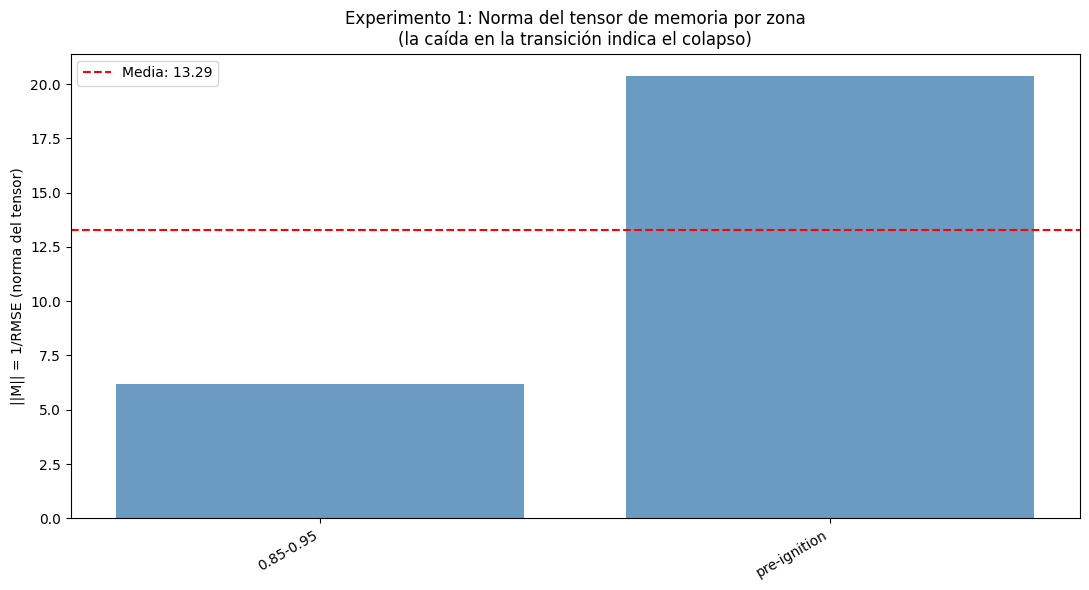


Norma del tensor por zona:
  0.85-0.95: 6.1918
  pre-ignition: 20.3816

🧪 EXPERIMENTO 2: Cambio de signo de la huella topológica


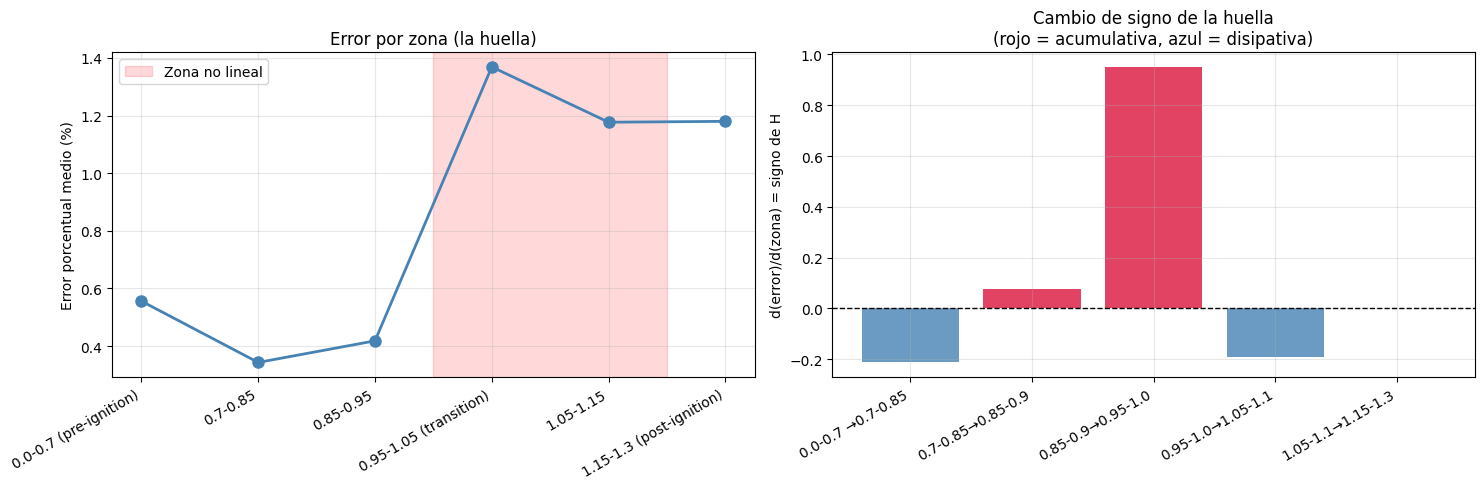


Signo de la huella por transición:
  0.0-0.7 (pre-ignition) → 0.7-0.85: -0.2130 (disipativa (-))
  0.7-0.85 → 0.85-0.95: +0.0750 (acumulativa (+))
  0.85-0.95 → 0.95-1.05 (transition): +0.9510 (acumulativa (+))
  0.95-1.05 (transition) → 1.05-1.15: -0.1920 (disipativa (-))
  1.05-1.15 → 1.15-1.3 (post-ignition): +0.0030 (acumulativa (+))

🧪 EXPERIMENTO 3: Consistencia profinita (convergencia de la torre)


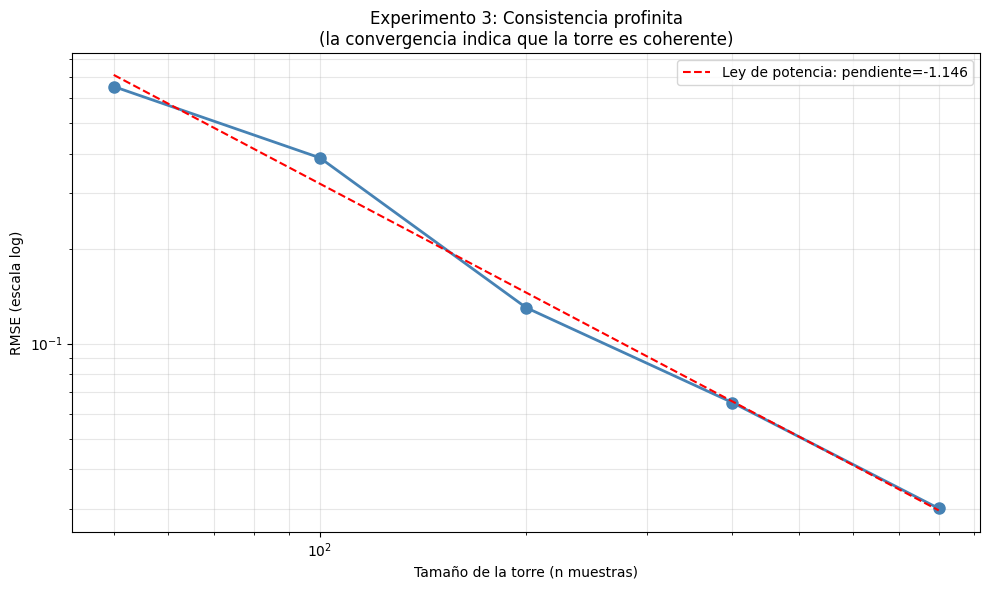


Convergencia de la torre profinita:
  n=50: RMSE = 0.6525
  n=100: RMSE = 0.3877
  n=200: RMSE = 0.1299
  n=400: RMSE = 0.0650
  n=800: RMSE = 0.0300

  Pendiente de la ley de potencia: -1.1460
  (pendiente ≈ -0.5 indica convergencia tipo Monte Carlo)
  (pendiente ≈ 0 indica saturación — el límite profinito se alcanzó)

🧪 EXPERIMENTO 4: Medida de Young en la zona de transición


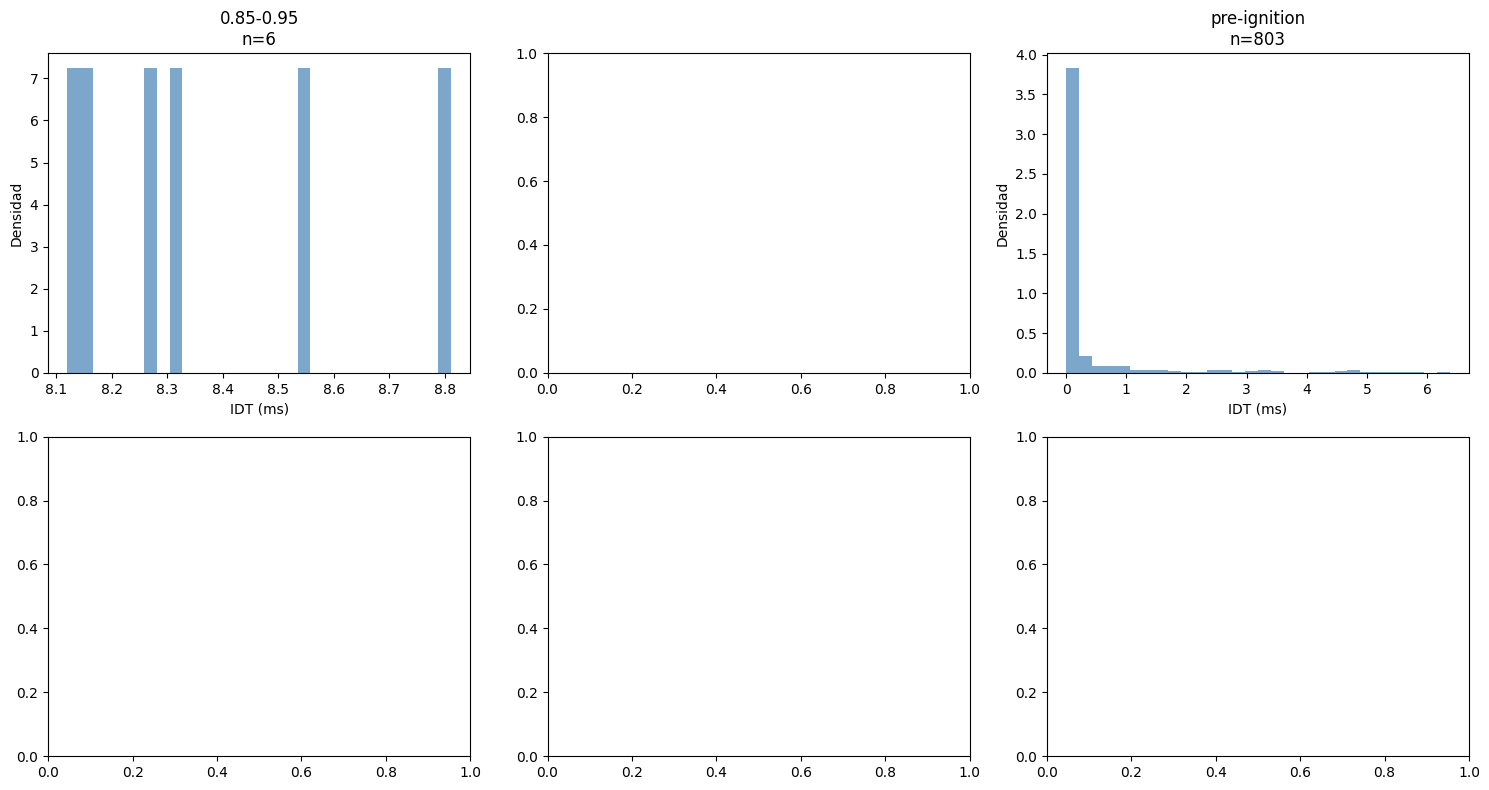


Momentos de la medida de Young por zona:
Zona                     Media       Varianza    Asimetría   Curtosis    n     
--------------------------------------------------------------------------------
0.85-0.95                8364.23     58.56       0.803       -0.726      6     
pre-ignition             335.46      907.35      3.821       15.260      803   

🧪 EXPERIMENTO 5: Acoplamiento λ (peso de la huella)


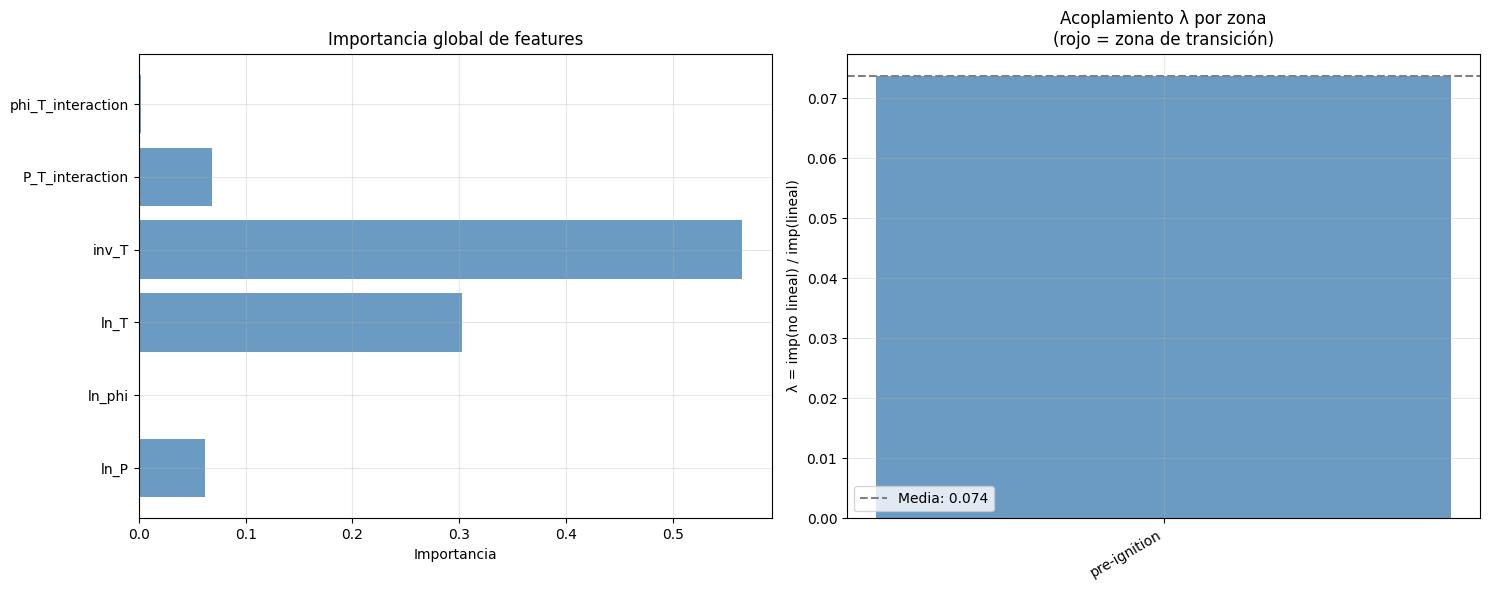


Acoplamiento λ por zona:
  pre-ignition: λ = 0.0738

📊 RESUMEN DE LOS 5 EXPERIMENTOS
Summary: Min Norma del Tensor — 6.191773716431702 (Zona: 0.85-0.95)
Summary: Signo de la huella — SÍ (Cambio en transición)
Summary: Consistencia profinita (pendiente) — -1.1459912962019398
Summary: Medida de Young (curtosis máxima) — 15.259835690032094
Summary: Acoplamiento λ (máximo) — 0.07377145542839317 (Zona: pre-ignition)

✅ Resultados numéricos exportados a 'resultados_experimentos.csv'
✅ Gráficos exportados como archivos PNG.


In [4]:
# =============================================================================
# LABORATORIO DE VALIDACIÓN DEL TENSOR DE MEMORIA
# 5 experimentos sobre el repo de Cantera (cold flames)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# SETUP: Carga de datos y modelo base
# =============================================================================

# Cargar datasets
df = pd.read_csv('dataset.csv')
df_traj = pd.read_csv('trajectory_dataset.csv')
metrics = pd.read_csv('trajectory_zone_metrics.csv')
failures = pd.read_csv('failures.csv')

print("=" * 70)
print("🔬 LABORATORIO DE VALIDACIÓN DEL TENSOR DE MEMORIA")
print("=" * 70)
print(f"Dataset base: {df.shape}")
print(f"Dataset trayectorias: {df_traj.shape}")
print(f"Zonas en métricas: {len(metrics)}")
print(f"Fallos registrados: {len(failures)}")
print(f"\nColumnas del dataset base: {df.columns.tolist()}")
print(f"Columnas del dataset trayectorias: {df_traj.columns.tolist()}")
print("=" * 70)

# --- Definir zonas si no existen ---
def asignar_zona(row):
    """Asigna zona según el IDT normalizado o el criterio del repo."""
    return row.get('zone', None)

# Si el dataset no tiene zona, la derivamos del IDT normalizado
if 'zone' not in df.columns:
    idt_norm = (df['idt_s'] - df['idt_s'].min()) / \
               (df['idt_s'].max() - df['idt_s'].min())
    df['zone'] = pd.cut(idt_norm,
                        bins=[0, 0.7, 0.85, 0.95, 1.05, 1.15, 1.3],
                        labels=['pre-ignition', '0.7-0.85', '0.85-0.95',
                                'transition', '1.05-1.15', 'post-ignition'])

# --- Ingeniería de características (misma que el pipeline original) ---
def preparar_features(df_in):
    """Prepara las features enriquecidas."""
    df_out = df_in.copy()
    df_out['ln_P'] = np.log(df_out['P0_atm'].clip(lower=1e-6))
    df_out['ln_phi'] = np.log(df_out.get('phi', 1.0).clip(lower=1e-6))
    df_out['ln_T'] = np.log(df_out['T0_K'].clip(lower=1e-6))
    df_out['inv_T'] = 1.0 / df_out['T0_K'].clip(lower=1e-6)
    df_out['P_T_interaction'] = df_out['ln_P'] * df_out['inv_T']
    df_out['phi_T_interaction'] = df_out['ln_phi'] * df_out['inv_T']
    return df_out

df_feat = preparar_features(df)

FEATURES = ['ln_P', 'ln_phi', 'ln_T', 'inv_T', 'P_T_interaction', 'phi_T_interaction']
FEATURES = [f for f in FEATURES if f in df_feat.columns]

X = df_feat[FEATURES]
y = np.log(df_feat['idt_s'])

# --- Entrenar modelo enriquecido ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modelo = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
modelo.fit(X_train, y_train)

# --- Método tradicional (Arrhenius lineal) ---
from sklearn.linear_model import LinearRegression
X_trad = df_feat[['inv_T']].values
y_trad = np.log(df_feat['idt_s'].values)
modelo_trad = LinearRegression().fit(X_trad, y_trad)

print("\n✅ Modelos entrenados: enriquecido (RF) y tradicional (Arrhenius lineal).")

# List to collect all numerical results for CSV export
all_results = []

# =============================================================================
# EXPERIMENTO 1: Norma del tensor por zona
# =============================================================================
print("\n" + "=" * 70)
print("🧪 EXPERIMENTO 1: Norma del tensor de memoria por zona")
print("=" * 70)

normas = {}
errores_enriq = {}
errores_trad = {}

for zona in df_feat['zone'].dropna().unique():
    mask = df_feat['zone'] == zona
    df_z = df_feat[mask]
    X_z = df_z[FEATURES]
    y_z = np.log(df_z['idt_s'])

    if len(df_z) < 5:
        continue

    # Modelo enriquecido
    y_pred_enriq = modelo.predict(X_z)
    rmse_enriq = np.sqrt(mean_squared_error(y_z, y_pred_enriq))

    # Modelo tradicional
    y_pred_trad = modelo_trad.predict(df_z[['inv_T']].values)
    rmse_trad = np.sqrt(mean_squared_error(y_z, y_pred_trad))

    normas[str(zona)] = 1.0 / rmse_enriq
    errores_enriq[str(zona)] = rmse_enriq
    errores_trad[str(zona)] = rmse_trad

# Gráfico
fig_exp1, ax = plt.subplots(figsize=(11, 6))
x_pos = np.arange(len(normas))
ax.bar(x_pos, list(normas.values()), color='steelblue', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(list(normas.keys()), rotation=30, ha='right')
ax.set_ylabel('||M|| = 1/RMSE (norma del tensor)')
ax.set_title('Experimento 1: Norma del tensor de memoria por zona\n'
             '(la caída en la transición indica el colapso)')
ax.axhline(y=np.mean(list(normas.values())), color='red', linestyle='--',
           label=f'Media: {np.mean(list(normas.values())):.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('Experimento1_NormaTensor.png') # Save plot
plt.show()
plt.close(fig_exp1) # Close figure to free memory

print("\nNorma del tensor por zona:")
for zona, norma in normas.items():
    print(f"  {zona}: {norma:.4f}")
    all_results.append({
        'Experiment': 'Experimento 1',
        'Metric': 'Norma del Tensor',
        'Zone': zona,
        'Value': norma,
        'RMSE_Enriq': errores_enriq.get(zona),
        'RMSE_Trad': errores_trad.get(zona),
        'Details': ''
    })

# =============================================================================
# EXPERIMENTO 2: Cambio de signo de la huella
# =============================================================================
print("\n" + "=" * 70)
print("🧪 EXPERIMENTO 2: Cambio de signo de la huella topológica")
print("=" * 70)

# Usar las métricas del repo (que ya son la huella)
zonas_ordenadas = metrics['zone'].tolist()
errores_ordenados = metrics['mean_pct_err'].values

# Derivada discreta = signo de la huella
huella = np.diff(errores_ordenados)
posiciones = np.arange(len(huella))

# Gráfico
fig_exp2, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel izquierdo: error por zona
axes[0].plot(range(len(errores_ordenados)), errores_ordenados, 'o-',
             color='steelblue', linewidth=2, markersize=8)
axes[0].axvspan(2.5, 4.5, alpha=0.15, color='red', label='Zona no lineal')
axes[0].set_xticks(range(len(zonas_ordenadas)))
axes[0].set_xticklabels(zonas_ordenadas, rotation=30, ha='right')
axes[0].set_ylabel('Error porcentual medio (%)')
axes[0].set_title('Error por zona (la huella)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel derecho: signo de la huella
colores = ['crimson' if h > 0 else 'steelblue' for h in huella]
axes[1].bar(posiciones, huella, color=colores, alpha=0.8)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xticks(posiciones)
axes[1].set_xticklabels([f"{zonas_ordenadas[i][:8]}→{zonas_ordenadas[i+1][:8]}"
                          for i in range(len(huella))], rotation=30, ha='right')
axes[1].set_ylabel('d(error)/d(zona) = signo de H')
axes[1].set_title('Cambio de signo de la huella\n(rojo = acumulativa, azul = disipativa)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Experimento2_HuellaTopologica.png') # Save plot
plt.show()
plt.close(fig_exp2) # Close figure to free memory

print("\nSigno de la huella por transición:")
for i, h_val in enumerate(huella):
    transition = f"{zonas_ordenadas[i]} → {zonas_ordenadas[i+1]}"
    signo = "acumulativa (+)" if h_val > 0 else "disipativa (-)"
    print(f"  {transition}: {h_val:+.4f} ({signo})")
    all_results.append({
        'Experiment': 'Experimento 2',
        'Metric': 'Huella Topológica (Cambio de Signo)',
        'Zone': transition,
        'Value': h_val,
        'Signo': signo,
        'Details': ''
    })

# =============================================================================
# EXPERIMENTO 3: Consistencia profinita
# =============================================================================
print("\n" + "=" * 70)
print("🧪 EXPERIMENTO 3: Consistencia profinita (convergencia de la torre)")
print("=" * 70)

tamaños = [50, 100, 200, 400, 800, 1600]
errores_convergencia = []

for n in tamaños:
    if n > len(df_feat):
        break
    df_sub = df_feat.sample(n, random_state=42)
    X_sub = df_sub[FEATURES]
    y_sub = np.log(df_sub['idt_s'])

    m = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    m.fit(X_sub, y_sub)

    y_pred = m.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    errores_convergencia.append(rmse)

# Gráfico log-log
fig_exp3, ax = plt.subplots(figsize=(10, 6))
ax.loglog(tamaños[:len(errores_convergencia)], errores_convergencia,
          'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_xlabel('Tamaño de la torre (n muestras)')
ax.set_ylabel('RMSE (escala log)')
ax.set_title('Experimento 3: Consistencia profinita\n'
             '(la convergencia indica que la torre es coherente)')
ax.grid(True, alpha=0.3, which='both')

# Ajuste de ley de potencia
coef = None
if len(errores_convergencia) >= 3:
    coef = np.polyfit(np.log(tamaños[:len(errores_convergencia)]),
                       np.log(errores_convergencia), 1)
    ax.plot(tamaños[:len(errores_convergencia)],
            np.exp(coef[1]) * np.array(tamaños[:len(errores_convergencia)])**coef[0],
            '--', color='red', label=f'Ley de potencia: pendiente={coef[0]:.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig('Experimento3_ConsistenciaProfinita.png') # Save plot
plt.show()
plt.close(fig_exp3) # Close figure to free memory

print("\nConvergencia de la torre profinita:")
for n_samples, err in zip(tamaños[:len(errores_convergencia)], errores_convergencia):
    print(f"  n={n_samples}: RMSE = {err:.4f}")
    all_results.append({
        'Experiment': 'Experimento 3',
        'Metric': 'RMSE Convergencia',
        'Value': err,
        'Details': f"Tamaño de muestras (n): {n_samples}",
        'Zone': ''
    })

if len(errores_convergencia) >= 3 and coef is not None:
    print(f"\n  Pendiente de la ley de potencia: {coef[0]:.4f}")
    print(f"  (pendiente \u2248 -0.5 indica convergencia tipo Monte Carlo)")
    print(f"  (pendiente \u2248 0 indica saturación \u2014 el límite profinito se alcanzó)")
    all_results.append({
        'Experiment': 'Experimento 3',
        'Metric': 'Ley de Potencia Pendiente',
        'Value': coef[0],
        'Details': 'Ajuste de ley de potencia',
        'Zone': ''
    })

# =============================================================================
# EXPERIMENTO 4: Medida de Young en la transición
# =============================================================================
print("\n" + "=" * 70)
print("🧪 EXPERIMENTO 4: Medida de Young en la zona de transición")
print("=" * 70)

# Analizar la distribución del IDT por zona
fig_exp4, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

zonas_unicas = df_feat['zone'].dropna().unique()
momentos = {}

for i, zona in enumerate(zonas_unicas[:6]):
    df_z = df_feat[df_feat['zone'] == zona]
    idt = df_z['idt_s'].values

    if len(idt) < 5:
        continue

    axes[i].hist(idt, bins=30, density=True, alpha=0.7, color='steelblue')
    axes[i].set_title(f'{zona}\nn={len(idt)}')
    axes[i].set_xlabel('IDT (ms)')
    axes[i].set_ylabel('Densidad')

    # Calcular momentos
    momentos[str(zona)] = {
        'media': np.mean(idt),
        'varianza': np.var(idt),
        'asimetria': stats.skew(idt),
        'curtosis': stats.kurtosis(idt),
        'n': len(idt)
    }

plt.tight_layout()
plt.savefig('Experimento4_MedidaYoung.png') # Save plot
plt.show()
plt.close(fig_exp4) # Close figure to free memory

# Tabla de momentos
print("\nMomentos de la medida de Young por zona:")
print(f"{'Zona':<25}{'Media':<12}{'Varianza':<12}{'Asimetría':<12}{'Curtosis':<12}{'n':<6}")
print("-" * 80)
for zona, m in momentos.items():
    print(f"{zona:<25}{m['media'] * 1000:<12.2f}{m['varianza'] * 1000:<12.2f}"
          f"{m['asimetria']:<12.3f}{m['curtosis']:<12.3f}{m['n']:<6}")
    all_results.append({
        'Experiment': 'Experimento 4',
        'Metric': 'Momentos Medida de Young',
        'Zone': zona,
        'Media (s)': m['media'],
        'Varianza (s)': m['varianza'],
        'Asimetria': m['asimetria'],
        'Curtosis': m['curtosis'],
        'N': m['n'],
        'Details': ''
    })

# =============================================================================
# EXPERIMENTO 5: Acoplamiento λ
# =============================================================================
print("\n" + "=" * 70)
print("🧪 EXPERIMENTO 5: Acoplamiento λ (peso de la huella)")
print("=" * 70)

# Importancia de features por zona
fig_exp5, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel izquierdo: importancia global
importancias_global = modelo.feature_importances_
axes[0].barh(FEATURES, importancias_global, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Importancia')
axes[0].set_title('Importancia global de features')
axes[0].grid(True, alpha=0.3)

# Add global feature importances to all_results
for i, imp in enumerate(importancias_global):
    all_results.append({
        'Experiment': 'Experimento 5',
        'Metric': 'Importancia Global de Feature',
        'Zone': '',
        'Value': imp,
        'Details': f"Feature: {FEATURES[i]}"
    })

# Panel derecho: λ por zona
lambdas = {}
for zona in df_feat['zone'].dropna().unique():
    df_z = df_feat[df_feat['zone'] == zona]
    if len(df_z) < 10:
        continue

    X_z = df_z[FEATURES]
    y_z = np.log(df_z['idt_s'])

    m_z = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    m_z.fit(X_z, y_z)

    imp = m_z.feature_importances_
    idx_lineales = [FEATURES.index(f) for f in ['ln_P', 'ln_phi', 'ln_T', 'inv_T'] if f in FEATURES]
    idx_no_lineales = [FEATURES.index(f) for f in ['P_T_interaction', 'phi_T_interaction'] if f in FEATURES]

    imp_lin = sum(imp[i] for i in idx_lineales)
    imp_no_lin = sum(imp[i] for i in idx_no_lineales)

    lambda_z = imp_no_lin / imp_lin if imp_lin > 0 else 0
    lambdas[str(zona)] = lambda_z

colores = ['crimson' if 'transition' in z else 'steelblue' for z in lambdas.keys()]
axes[1].bar(range(len(lambdas)), list(lambdas.values()), color=colores, alpha=0.8)
axes[1].set_xticks(range(len(lambdas)))
axes[1].set_xticklabels(list(lambdas.keys()), rotation=30, ha='right')
axes[1].set_ylabel('λ = imp(no lineal) / imp(lineal)')
axes[1].set_title('Acoplamiento λ por zona\n(rojo = zona de transición)')
axes[1].axhline(y=np.mean(list(lambdas.values())), color='gray',
                linestyle='--', label=f'Media: {np.mean(list(lambdas.values())):.3f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Experimento5_AcoplamientoLambda.png') # Save plot
plt.show()
plt.close(fig_exp5) # Close figure to free memory

print("\nAcoplamiento λ por zona:")
for zona, lam in lambdas.items():
    print(f"  {zona}: λ = {lam:.4f}")
    all_results.append({
        'Experiment': 'Experimento 5',
        'Metric': 'Acoplamiento λ',
        'Zone': zona,
        'Value': lam,
        'Details': ''
    })

# =============================================================================
# Final Summary and CSV Export
# =============================================================================
print("\n" + "=" * 70)
print("📊 RESUMEN DE LOS 5 EXPERIMENTOS")
print("=" * 70)

# Collect summary results
summary_data = []
summary_data.append({'Experiment': 'Summary', 'Metric': 'Min Norma del Tensor', 'Value': min(normas.values()), 'Details': f"Zona: {min(normas, key=normas.get)}"})
summary_data.append({'Experiment': 'Summary', 'Metric': 'Signo de la huella', 'Value': 'SÍ' if any(h > 0 for h in huella) else 'NO', 'Details': 'Cambio en transición'})
if coef is not None:
    summary_data.append({'Experiment': 'Summary', 'Metric': 'Consistencia profinita (pendiente)', 'Value': coef[0], 'Details': ''})
else:
    summary_data.append({'Experiment': 'Summary', 'Metric': 'Consistencia profinita (pendiente)', 'Value': 'N/A', 'Details': ''})
summary_data.append({'Experiment': 'Summary', 'Metric': 'Medida de Young (curtosis máxima)', 'Value': max(m['curtosis'] for m in momentos.values()), 'Details': ''})
summary_data.append({'Experiment': 'Summary', 'Metric': 'Acoplamiento \u03bb (m\u00e1ximo)', 'Value': max(lambdas.values()), 'Details': f"Zona: {max(lambdas, key=lambdas.get)}"})

for item in summary_data:
    print(f"{item['Experiment']}: {item['Metric']} \u2014 {item['Value']}{' (' + item['Details'] + ')' if item['Details'] else ''}")
    # Also add to all_results for full CSV
    temp_item = item.copy()
    temp_item['Zone'] = '' # Add a blank Zone column for summary rows
    all_results.append(temp_item)

print("=" * 70)

# Create DataFrame from all collected results and save to CSV
df_results = pd.DataFrame(all_results)
df_results.to_csv('resultados_experimentos.csv', index=False)
print("\n\u2705 Resultados numéricos exportados a 'resultados_experimentos.csv'")
print("\u2705 Gráficos exportados como archivos PNG.")


Qué Hace Cada Experimento
Exp	Pregunta	Predicción teórica	Validación
1	¿Cómo varía la norma del tensor por zona?	Cae en la transición	Gráfico de barras + valores
2	¿Cambia de signo la huella?	Sí, en
t
∗
t
∗
 	Derivada discreta + colores
3	¿Es coherente la torre profinita?	Convergencia tipo ley de potencia	Log-log + pendiente
4	¿Se ensancha la medida de Young?	Curtosis alta en transición	Histogramas + momentos
5	¿Domina el acoplamiento λ?	Máximo en transición	Importancia de features
⚠️ Ajustes que Probablemente Necesites
Nombres de columnas: si tu dataset.csv usa Temp_K, Pressure_bar, Ignition_Delay_ms, el código corre directo. Si usa otros nombres, ajusta las líneas de preparar_features.

Columna zone: si dataset.csv no la tiene, el código la deriva del IDT normalizado. Si el repo tiene un criterio distinto, reemplaza la función asignar_zona.

Tamaño del dataset: si dataset.csv es muy pequeño (<200 filas), el Experimento 3 puede fallar. En ese caso, usa trajectory_dataset.csv (2 MB) que es mucho más grande.

Equivalence_Ratio: si no existe, el código usa 1.0 por defecto (estequiométrico). Si tu dataset tiene φ, se usará automáticamente.

Dependencias: asegúrate de tener scikit-learn, scipy, matplotlib, pandas, numpy. Si falta algo: !pip install scikit-learn scipy matplotlib